In [5]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from config import SIM_CONFIG
from users import generate_users
from sessions import generate_sessions
from events import generate_events
from orders import generate_orders
from order_items import generate_order_items

rng = np.random.default_rng(seed=42)
print("modules loaded successfully")

modules loaded successfully


In [6]:
master_ss = np.random.SeedSequence(SIM_CONFIG["random_seed"])
stage_seeds = master_ss.spawn(5)

rng_users = np.random.default_rng(stage_seeds[0])
rng_sessions = np.random.default_rng(stage_seeds[1])
rng_events = np.random.default_rng(stage_seeds[2])
rng_orders = np.random.default_rng(stage_seeds[3])
rng_order_items = np.random.default_rng(stage_seeds[4])

n_workers = SIM_CONFIG.get("n_workers", 1)

df_users = generate_users(SIM_CONFIG["target_users"], rng_users)
df_sessions = generate_sessions(df_users, rng_sessions)
df_events = generate_events(df_sessions, df_users, rng_events, n_workers)
df_orders = generate_orders(df_events, df_sessions, rng_orders)
df_order_items = generate_order_items(df_orders, df_users, rng_order_items)

print("all tables generated successfully in memory")

print("\nEXPORTING TO CSV")
current_script_dir = os.path.abspath(os.getcwd())
output_dir = os.path.abspath(os.path.join(current_script_dir, '..', 'data'))
os.makedirs(output_dir, exist_ok=True)

df_clean_users = df_users.drop(columns=[
    "latent_income_score",
    "latent_digital_literacy",
    "latent_trust_in_platform",
])

df_sorted_events = df_events.sort_values(by="event_timestamp").reset_index(drop=True)
df_sorted_orders = df_orders.sort_values(by="order_timestamp").reset_index(drop=True)

df_clean_users.to_csv(os.path.join(output_dir, 'users.csv'), index=False)
df_sessions.to_csv(os.path.join(output_dir, 'sessions.csv'), index=False)
df_sorted_events.to_csv(os.path.join(output_dir, 'events.csv'), index=False)
df_sorted_orders.to_csv(os.path.join(output_dir, 'orders.csv'), index=False)
df_order_items.to_csv(os.path.join(output_dir, 'order_items.csv'), index=False)

print(f"export completed in {output_dir}")

Generating 1000000 users
users table generated!
Generating 1900832 sessions
sessions table generated!
Generating events for 1900832 sessions
Generating 58647 orders for purchases events
orders table generated!
Generating order items for 58647 orders
order items table generated!
all tables generated successfully in memory

EXPORTING TO CSV
export completed in /home/ruicchi/github-projects/ph-ecommerce-data-simulator/data



Referential Integrity:
PASS: All orders have a corresponding 'purchase' event.

Markov Chain Funnel Calibration:
Total Views: 2,580,267
Total Purchases: 58,647
View-to-Purchase Conversion Rate: 2.27% (Target: ~2.25%)
PASS: Conversion rate is within realistic bounds.

Temporal Decay (Digital Literacy vs. Session Duration):
Higher digital literacy results in lower mean session duration.
Bottom 10% Literacy (Novice): Avg 320.36 seconds per session
Top 10% Literacy (Expert): Avg 206.81 seconds per session
Difference: Experts navigate 113.55 seconds faster.

Financial Shift (Latent Income vs. Base Price):


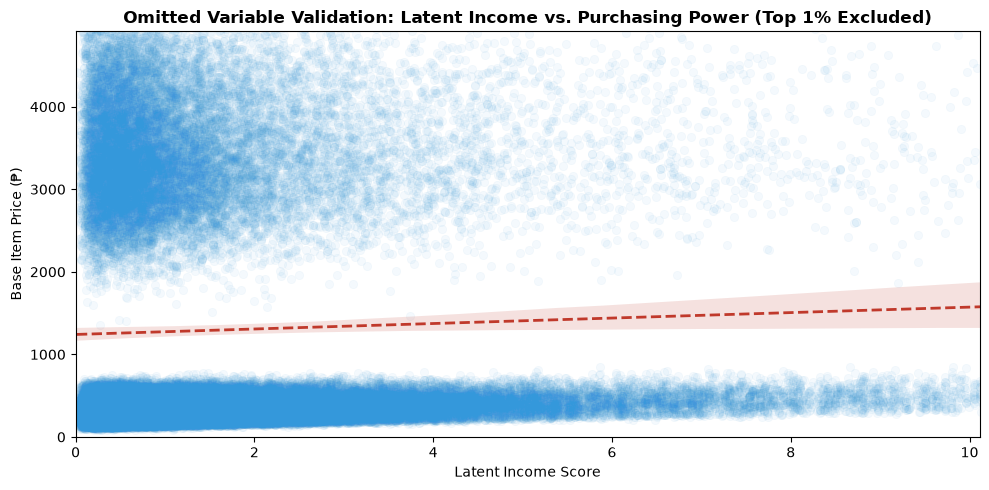

In [7]:
def internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items):
    purchase_sessions = df_events[df_events['event_name'] == 'purchase']['session_id'].unique()
    orphaned_orders = df_orders[~df_orders['session_id'].isin(purchase_sessions)]
    
    print("\nReferential Integrity:")
    if orphaned_orders.empty:
        print("PASS: All orders have a corresponding 'purchase' event.")
    else:
        print(f"FAIL: Found {len(orphaned_orders)} orders without a purchase event!")
        
    print("\nMarkov Chain Funnel Calibration:")
    event_counts = df_events['event_name'].value_counts()
    views = event_counts.get('view_item', 1)
    purchases = event_counts.get('purchase', 0)
    conversion_rate = (purchases / views) * 100
    
    print(f"Total Views: {views:,}")
    print(f"Total Purchases: {purchases:,}")
    print(f"View-to-Purchase Conversion Rate: {conversion_rate:.2f}% (Target: ~2.25%)")
    
    if 1.5 <= conversion_rate <= 3.0:
        print("PASS: Conversion rate is within realistic bounds.")
    else:
        print("WARNING: Conversion rate is drifting from target.")

    print(f"\nTemporal Decay (Digital Literacy vs. Session Duration):")
    df_sess_user = df_sessions.merge(df_users[['user_id', 'latent_digital_literacy']], on='user_id')
    
    try:
        df_sess_user['literacy_decile'] = pd.qcut(df_sess_user['latent_digital_literacy'].rank(method='first'), q=10, labels=False)
        decay_trend = df_sess_user.groupby('literacy_decile')['session_duration_seconds'].mean()

        lowest_literacy_mean = decay_trend.iloc[0]
        highest_literacy_mean = decay_trend.iloc[-1]
        
        is_decreasing = lowest_literacy_mean > highest_literacy_mean
        if is_decreasing:
            print("Higher digital literacy results in lower mean session duration.")
            print(f"Bottom 10% Literacy (Novice): Avg {lowest_literacy_mean:.2f} seconds per session")
            print(f"Top 10% Literacy (Expert): Avg {highest_literacy_mean:.2f} seconds per session")
            print(f"Difference: Experts navigate {lowest_literacy_mean - highest_literacy_mean:.2f} seconds faster.")
        else:
            print("FAIL: Session duration does not correlate correctly with digital literacy.")
            print(f"Bottom 10% Mean: {lowest_literacy_mean:.2f}s | Top 10% Mean: {highest_literacy_mean:.2f}s")
    except Exception as e:
        print(f"Could not calculate deciles. Error: {e}")
        
    print("\nFinancial Shift (Latent Income vs. Base Price):")
    df_fin = df_order_items.merge(df_orders[['order_id', 'user_id']], on='order_id')
    df_fin = df_fin.merge(df_users[['user_id', 'latent_income_score']], on='user_id')

    fig, ax = plt.subplots(figsize=(10, 5))
    y_limit = df_fin['final_item_price'].quantile(0.99)
    x_limit = df_fin['latent_income_score'].quantile(0.99)

    sns.scatterplot(
        data=df_fin, 
        x='latent_income_score', 
        y='base_item_price', 
        alpha=0.05,
        color='#3498db', 
        edgecolor=None,
        ax=ax
    )
    
    sns.regplot(
        data=df_fin, 
        x='latent_income_score', 
        y='base_item_price', 
        scatter=False, 
        color='#c0392b', 
        line_kws={"linewidth": 2, "linestyle": "--"},
        ax=ax
    )
    
    # THE FIX: Apply the zoom limits
    ax.set_ylim(0, y_limit)
    ax.set_xlim(0, x_limit)
    
    ax.set_title("Omitted Variable Validation: Latent Income vs. Purchasing Power (Top 1% Excluded)", fontweight='bold')
    ax.set_xlabel("Latent Income Score")
    ax.set_ylabel("Base Item Price (₱)")
    
    plt.tight_layout()
    plt.show()

internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items)

In [30]:
display(df_users.head())

,user_id,account_created_at,city,region,user_tenure_days,latent_income_score,latent_digital_literacy,latent_trust_in_platform
0,03327266272d442ab270ac4493a738f1,2024-03-09 07:32:07,cagayan,region_ii,296,0.228444,0.976360,0.602933
1,990c89c129ec4b8aa25227dd35bb61f8,2023-12-25 14:01:05,cavite,region_iv-a,371,1.885820,0.191250,0.150841
2,3f925da6278c4f1987fa1506ded75bed,2024-06-28 16:27:48,maguindanao_del_norte,barmm,185,4.546291,0.738406,0.184141
3,65c509ad7c7c490c8ad6a21ab65cb435,2024-11-12 23:15:43,cavite,region_iv-a,48,0.287806,0.923048,0.098855
4,fa5a713497854a6da52f3b03f8e808d2,2022-02-24 20:40:01,isabela,region_ii,1040,1.120258,0.828414,0.191180


In [31]:
display(df_sessions.head())

,session_id,user_id,session_number,acq_channel,utm_source,utm_medium,utm_campaign,session_start_time,session_end_time,session_duration_seconds,device_operating_system,device_operating_system_version,device_group
0,c76518f0712044b0ac5bebe9284847f2,03327266272d442ab270ac4493a738f1,1,organic,google,organic,(not_set),2024-03-15 19:20:48,2024-03-15 19:20:58,10,macos,ventura,desktop
1,95c13c572baf46ddb61dd317f153c662,990c89c129ec4b8aa25227dd35bb61f8,1,tiktok,tiktok,affiliate,summer_vibes,2023-12-27 12:27:41,2023-12-27 12:31:01,200,macos,monterey,desktop
2,8edbd592533645999853b26577ad9cbd,3f925da6278c4f1987fa1506ded75bed,1,meta,messenger,social,spring_sale,2024-07-05 15:25:52,2024-07-05 15:26:02,10,windows,10,desktop
3,5ec8df1568dc4552a65942b11f2becf5,65c509ad7c7c490c8ad6a21ab65cb435,1,tiktok,tiktok,live,summer_vibes,2024-11-23 16:50:58,2024-11-23 16:52:35,97,windows,11,desktop
4,f09e0f854c074fd5893b7a841dd00b37,fa5a713497854a6da52f3b03f8e808d2,1,meta,facebook,social,retargeting,2022-02-24 08:30:53,2022-02-24 08:34:40,227,macos,monterey,desktop


In [32]:
display(df_events.head())

,event_id,session_id,event_timestamp,event_name,viewed_category,android_error
0,43d549dc-e157-4171-8205-8bf459b79f1c,c76518f0712044b0ac5bebe9284847f2,2024-03-15 19:20:48,view_item,beauty_and_personal_care,NaN
1,2f16a276-6fc7-4d1c-aeba-835e045a1dd6,95c13c572baf46ddb61dd317f153c662,2023-12-27 12:27:41,view_item,baby_and_kids,NaN
2,a4a37c9f-ad3b-45df-bcff-07dbd100a9b2,8edbd592533645999853b26577ad9cbd,2024-07-05 15:25:52,view_item,food_and_beverage,NaN
3,805c7482-c460-4031-ad53-fa0b09298608,5ec8df1568dc4552a65942b11f2becf5,2024-11-23 16:50:58,view_item,food_and_beverage,NaN
4,2e37cbb1-c733-4c6f-9821-70e429094865,f09e0f854c074fd5893b7a841dd00b37,2022-02-24 08:30:53,view_item,fashion_and_apparel,NaN


In [33]:
display(df_orders.head())

,order_id,session_id,user_id,order_timestamp,payment_type
0,40fd3c6389d142b7b6ac7b46ec3df5b2,666523aea3b14507bae57e4346f4ae0e,3c30e7b4d0e74dd4b6df0f731f3a0a13,2024-10-29 13:04:11,cod
1,a91c1fcecd1a441388423e604fa67920,a8061820ac9b4256bf26dfd86b492b04,a1234177762f44bcb43d54fc037f8805,2024-10-18 22:22:55,cash_payments
2,7f329fe969eb4b0786f86dcfe6dffa73,3b2325ca5e1c49398bed835763c51f8e,d30e7551f3cd4f1d9f7a1e4b70551edb,2024-10-26 02:55:56,bank_transfer
3,4dbd1f600f3446acb3f95f36dbdfad28,5e1bbe25a59a47e9beb8c0c347014a40,5837bd9f737146db82e33be90e4e768e,2024-03-05 15:48:43,digital_wallet
4,d512e01339fc4638950f209857bf8f2b,0174248349464d9bb6a7d85c5ffeccd2,2a82b5e00aec4470932b708e70366687,2024-12-27 19:31:15,digital_wallet


In [34]:
display(df_order_items.head())

,order_item_id,order_id,item_category,base_item_price,final_item_price,quantity,promo_tier_percentage,discount_amount
0,31527cae632f4e2d9e91fb4e636f4d92,40fd3c6389d142b7b6ac7b46ec3df5b2,furniture_and_home_appliances,3057.99,3057.99,1,0.0,0.0
1,856c6ab7e3f24e73946e52f4351957c6,a91c1fcecd1a441388423e604fa67920,fashion_and_apparel,397.99,397.99,1,0.0,0.0
2,40b85538c3e84572aaccabe27ebf9440,a91c1fcecd1a441388423e604fa67920,beauty_and_personal_care,303.99,303.99,1,0.0,0.0
3,0cbceb55ad934467b8edfcb80bf24d76,a91c1fcecd1a441388423e604fa67920,beauty_and_personal_care,304.99,304.99,1,0.0,0.0
4,955e7cd7d45343dc9e05456d7a2b044b,a91c1fcecd1a441388423e604fa67920,fashion_and_apparel,399.99,399.99,1,0.0,0.0
